# FGVD Research Visualisations

Comprehensive figures for the research report covering:
1. Sample vehicle crops and reconstructed feature images
2. Node features (RGB, Gabor, Sobel) visualised as 64×64 images
3. Graph topology (8-neighbour grid connectivity)
4. Edge weight computation (Gaussian RGB-similarity heatmaps)
5. Deep feature activation heatmap
6. Class-label hierarchy tree
7. Class-support distribution (long-tail analysis)
8. Results comparison table and bar charts
9. Method × Level performance heatmap
10. Learning curves overlay

All figures are saved to `visuals/`.

In [16]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe
from collections import Counter

ROOT      = Path('FGVD_Graph_Handover')
CKPT      = Path('checkpoints')
RESULTS   = Path('results')
VIS_DIR   = Path('visuals')
VIS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

metadata = pd.read_csv(ROOT / 'metadata.csv')
for c in ['vehicle_id','split','L1','L2','L3']:
    metadata[c] = metadata[c].astype(str).str.strip()

print('Metadata rows:', len(metadata))
print('Visualisations will be saved to:', VIS_DIR.resolve())

Metadata rows: 24450
Visualisations will be saved to: /home/user/Desktop/btech_project/visuals


---
## Fig 1 — Multi-vehicle panel: one crop per L1 class

Each crop is reconstructed from its stored RGB node features (shape `(4096, 3)`, rescaled ×255) by reshaping to 64×64×3. This shows what the model actually sees at the pixel level.

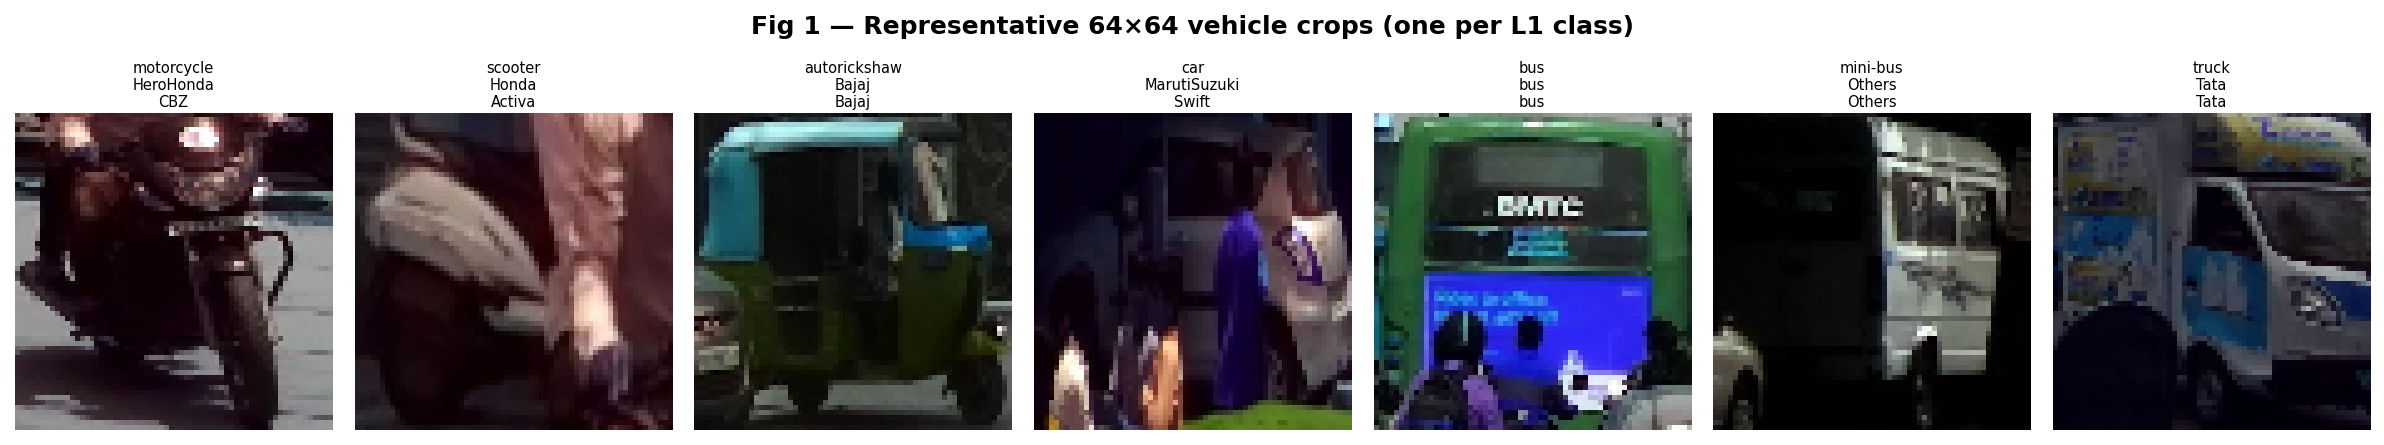

Saved fig1_vehicle_panel.png


In [17]:
L1_CLASSES = ['motorcycle','scooter','autorickshaw','car','bus','mini-bus','truck']

def load_rgb_image(vehicle_id, split):
    arr = np.load(ROOT / 'raw_features' / 'rgb' / split / f'{vehicle_id}.npy')
    img = (arr.reshape(64, 64, 3) * 255).clip(0, 255).astype(np.uint8)
    # features stored as BGR -> convert to RGB for display
    return img[:, :, ::-1]

# Pick one representative vehicle per L1 class from test split
samples = {}
for l1 in L1_CLASSES:
    row = metadata[(metadata.split == 'test') & (metadata.L1 == l1)].iloc[0]
    samples[l1] = row

fig, axes = plt.subplots(1, 7, figsize=(16, 3))
fig.suptitle('Fig 1 — Representative 64×64 vehicle crops (one per L1 class)',
             fontsize=12, fontweight='bold', y=1.02)

for ax, l1 in zip(axes, L1_CLASSES):
    row = samples[l1]
    img = load_rgb_image(row.vehicle_id, row.split)
    ax.imshow(img, interpolation='nearest')
    ax.set_title(f'{l1}\n{row.L2}\n{row.L3}', fontsize=7, pad=3)
    ax.axis('off')

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig1_vehicle_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_vehicle_panel.png')

---
## Fig 2 — Node feature deep-dive for one vehicle

Shows all eight node-feature channels for a single crop: RGB (3ch), Gabor at 4 orientations (4ch), Sobel magnitude (1ch). Each channel is displayed as a 64×64 heatmap. These are the raw graph node attributes used by SGCN.

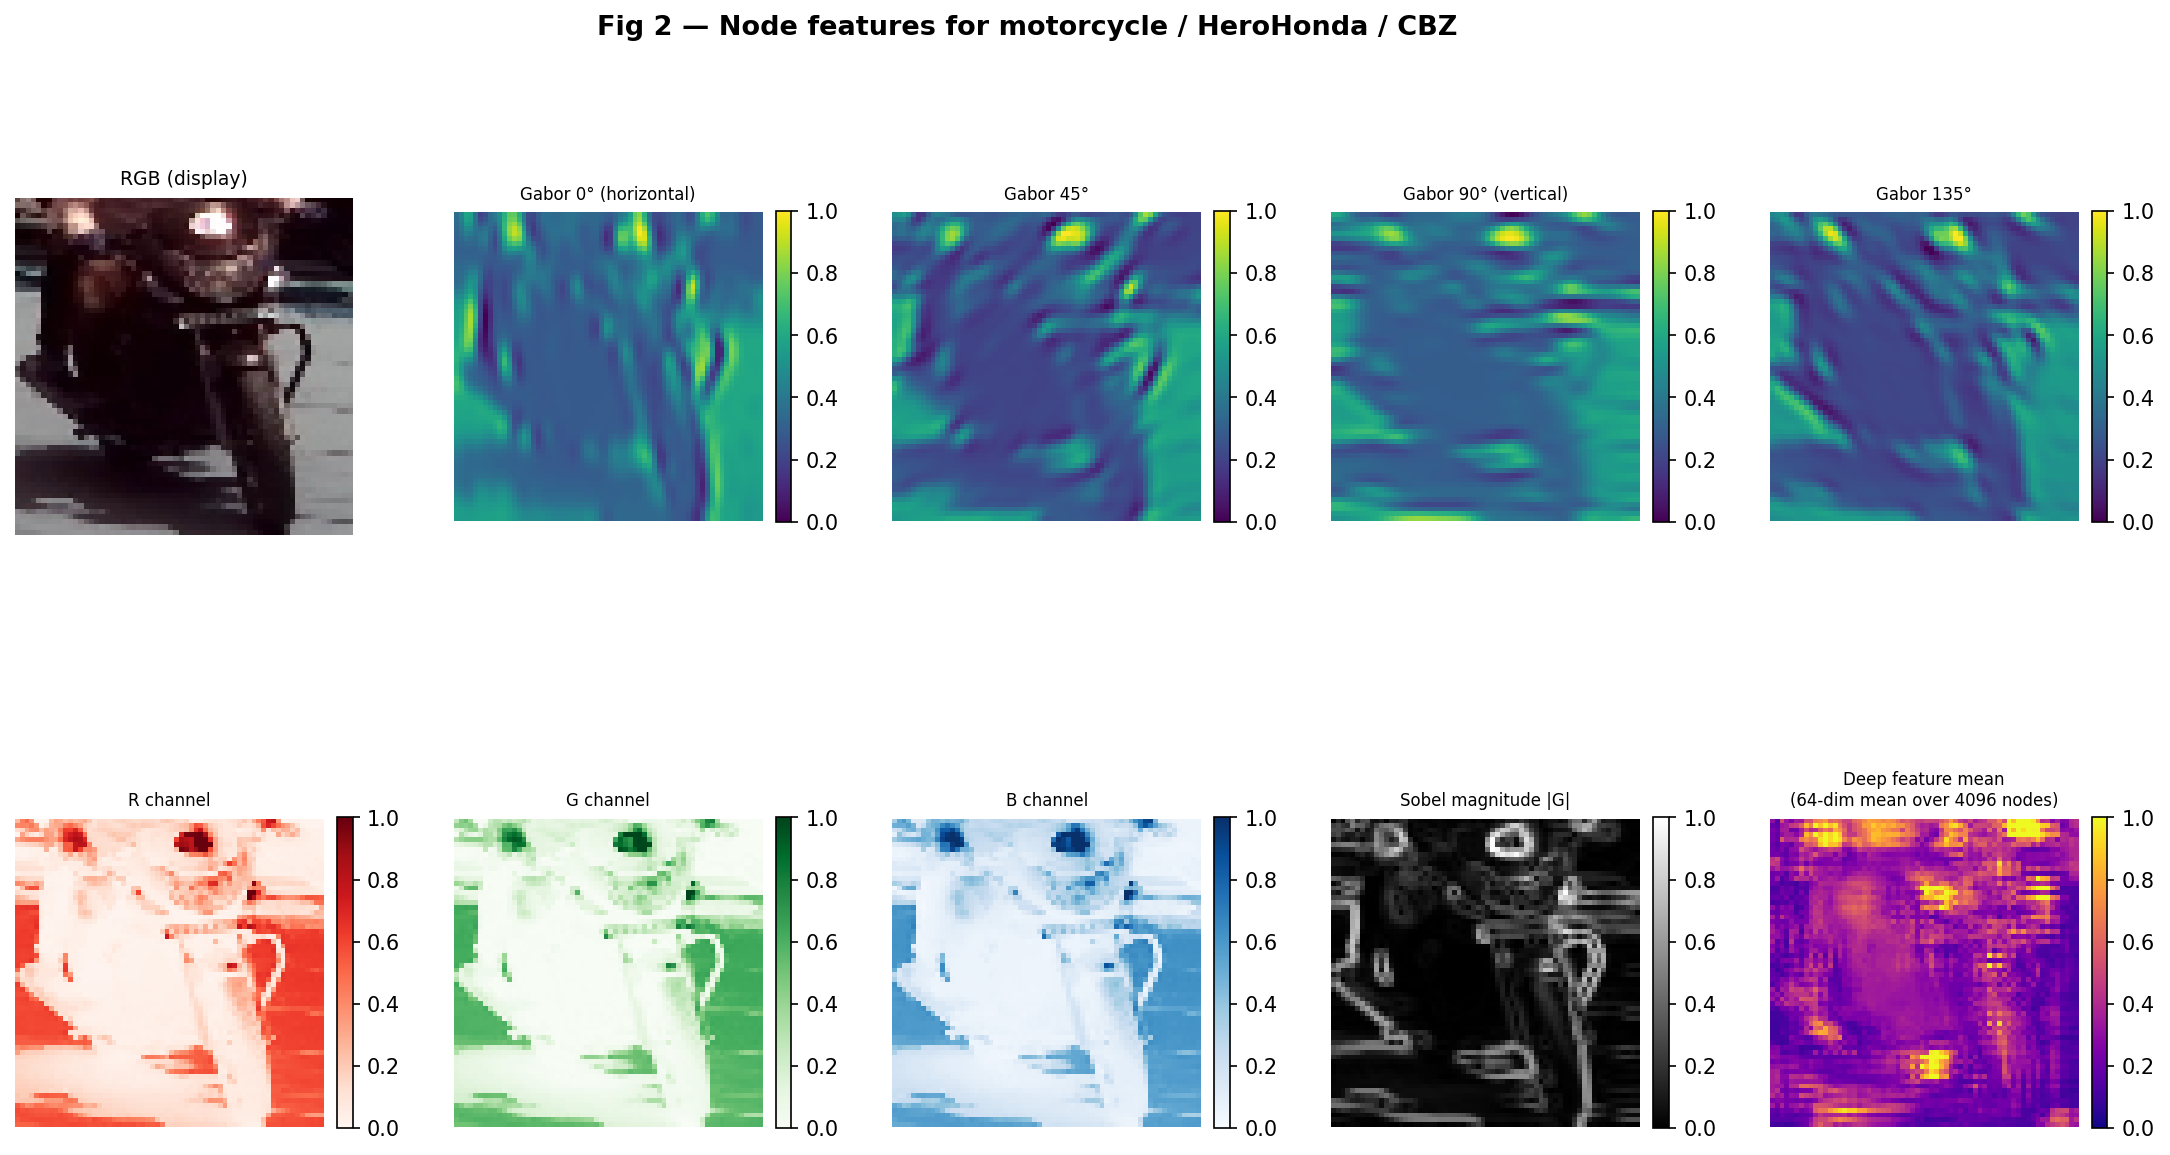

Saved fig2_node_features.png


In [18]:
# Use the motorcycle sample — most feature-rich for texture
demo = samples['motorcycle']
vid, sp = demo.vehicle_id, demo.split

rgb   = np.load(ROOT / 'raw_features' / 'rgb'   / sp / f'{vid}.npy').reshape(64, 64, 3)
gabor = np.load(ROOT / 'raw_features' / 'gabor' / sp / f'{vid}.npy').reshape(64, 64, 4)
sobel = np.load(ROOT / 'raw_features' / 'sobel' / sp / f'{vid}.npy').reshape(64, 64)
deep  = np.load(ROOT / 'deep_features' / 'multilevel' / sp / f'{vid}.npy').reshape(64, 64, 64)

GABOR_LABELS = ['Gabor 0° (horizontal)','Gabor 45°','Gabor 90° (vertical)','Gabor 135°']

fig = plt.figure(figsize=(18, 9))
fig.suptitle(f'Fig 2 — Node features for {demo.L1} / {demo.L2} / {demo.L3}',
             fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.4, wspace=0.3)

# Row 1: RGB + Gabor 0 + Gabor 45 + Gabor 90 + Gabor 135
ax_rgb = fig.add_subplot(gs[0, 0])
ax_rgb.imshow((rgb[:, :, ::-1] * 255).clip(0,255).astype(np.uint8), interpolation='nearest')
ax_rgb.set_title('RGB (display)', fontsize=9); ax_rgb.axis('off')

for i in range(4):
    ax = fig.add_subplot(gs[0, i+1])
    im = ax.imshow(gabor[:, :, i], cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(GABOR_LABELS[i], fontsize=8); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Row 2: R channel, G channel, B channel, Sobel, Deep feature energy
for i, (ch_arr, label, cmap) in enumerate([
    (rgb[:,:,0], 'R channel', 'Reds'),
    (rgb[:,:,1], 'G channel', 'Greens'),
    (rgb[:,:,2], 'B channel', 'Blues'),
    (sobel,      'Sobel magnitude |G|', 'gray'),
    (deep.mean(axis=2), 'Deep feature mean\n(64-dim mean over 4096 nodes)', 'plasma'),
]):
    ax = fig.add_subplot(gs[1, i])
    im = ax.imshow(ch_arr, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(label, fontsize=8); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.savefig(VIS_DIR / 'fig2_node_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_node_features.png')

---
## Fig 3 — Graph topology: 8-neighbour grid connectivity

Illustrates the grid graph structure on a 6×6 sub-grid. Each pixel is a **node**; edges connect every pixel to its 8 spatial neighbours (N, NE, E, SE, S, SW, W, NW). The full graph has 4096 nodes (64×64 grid) and 32,004 edges.

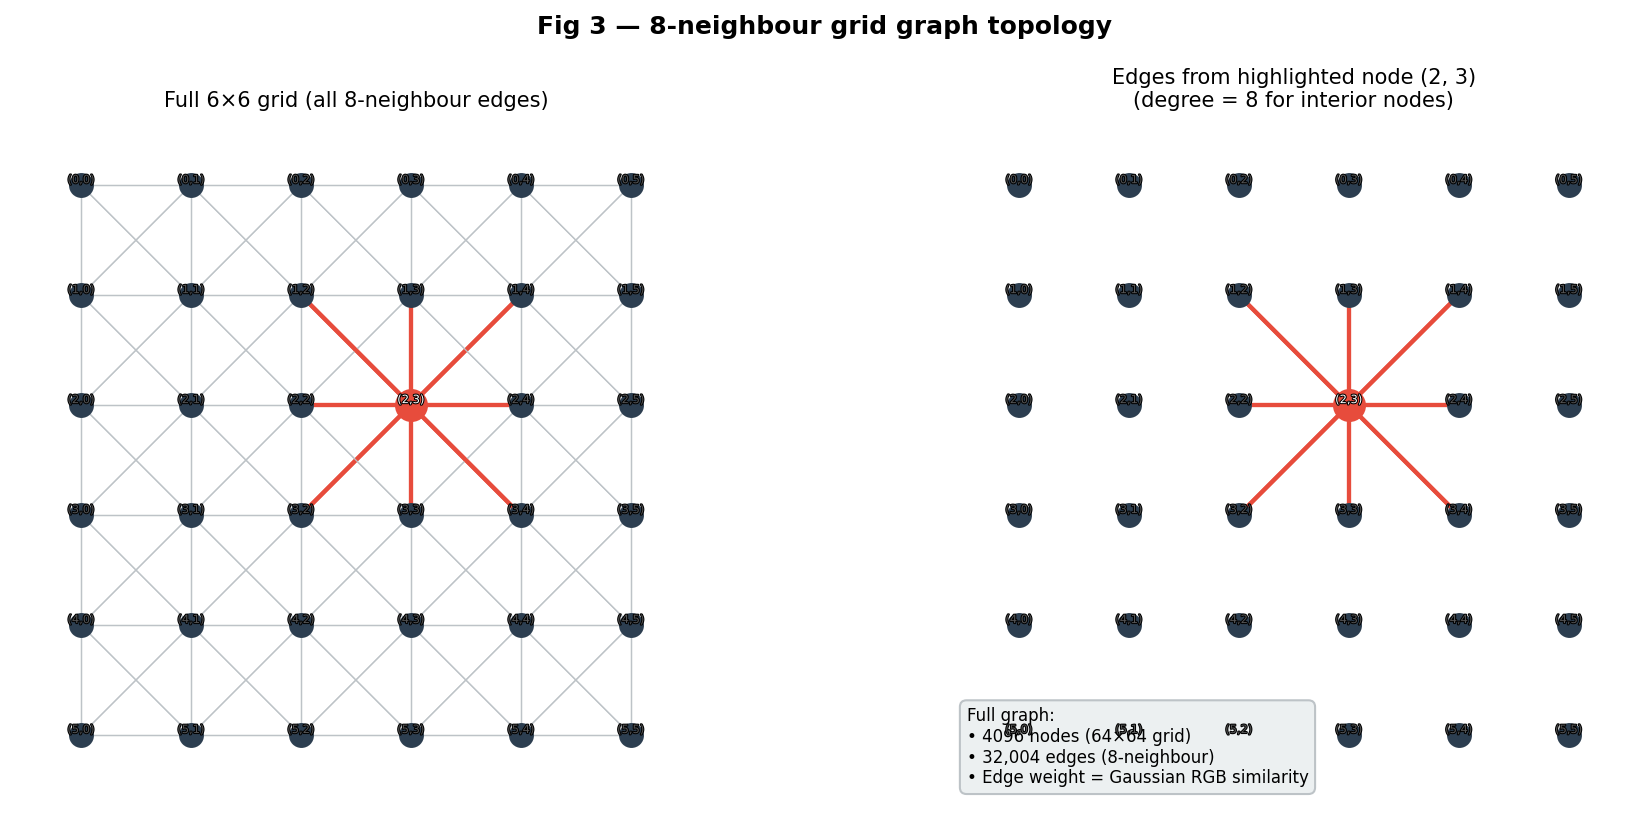

Saved fig3_graph_topology.png


In [19]:
GRID = 6          # show 6×6 sub-grid
HIGHLIGHT = (2, 3)  # node to highlight with all its edges

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Fig 3 — 8-neighbour grid graph topology', fontsize=12, fontweight='bold')

for ax, show_all in zip(axes, [True, False]):
    for r in range(GRID):
        for c in range(GRID):
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0:
                        continue
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < GRID and 0 <= nc < GRID:
                        is_highlight = (r == HIGHLIGHT[0] and c == HIGHLIGHT[1]) or \
                                       (nr == HIGHLIGHT[0] and nc == HIGHLIGHT[1])
                        if show_all or is_highlight:
                            color = '#e74c3c' if is_highlight else '#bdc3c7'
                            lw    = 2.0 if is_highlight else 0.6
                            ax.plot([c, nc], [r, nr], color=color, lw=lw, zorder=1)

    for r in range(GRID):
        for c in range(GRID):
            is_center = (r == HIGHLIGHT[0] and c == HIGHLIGHT[1])
            color = '#e74c3c' if is_center else '#2c3e50'
            size  = 220 if is_center else 120
            ax.scatter(c, r, s=size, color=color, zorder=3)
            ax.text(c, r, f'({r},{c})', fontsize=5.5, ha='center', va='bottom',
                    color='white' if is_center else '#555', zorder=4,
                    path_effects=[pe.withStroke(linewidth=1, foreground='black')])

    ax.set_xlim(-0.6, GRID - 0.4)
    ax.set_ylim(GRID - 0.4, -0.6)
    ax.set_aspect('equal')
    ax.axis('off')
    if show_all:
        ax.set_title(f'Full {GRID}×{GRID} grid (all 8-neighbour edges)', fontsize=10)
    else:
        ax.set_title(f'Edges from highlighted node {HIGHLIGHT}\n(degree = 8 for interior nodes)', fontsize=10)

# Annotation box
axes[1].text(0.02, 0.02,
    'Full graph:\n• 4096 nodes (64×64 grid)\n• 32,004 edges (8-neighbour)\n• Edge weight = Gaussian RGB similarity',
    transform=axes[1].transAxes, fontsize=8, va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', fc='#ecf0f1', ec='#bdc3c7'))

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig3_graph_topology.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3_graph_topology.png')

---
## Fig 4 — Edge weight computation: Gaussian RGB-similarity

Shows how edge weights are assigned. For every pair of 8-connected nodes (u, v), the weight is:

$$w_{uv} = \exp\!\left(-\frac{\|\text{RGB}_u - \text{RGB}_v\|^2}{2\sigma^2}\right), \quad \sigma = 0.5$$

High weight = similar colour neighbours (smooth region). Low weight = dissimilar colours (edge/boundary).

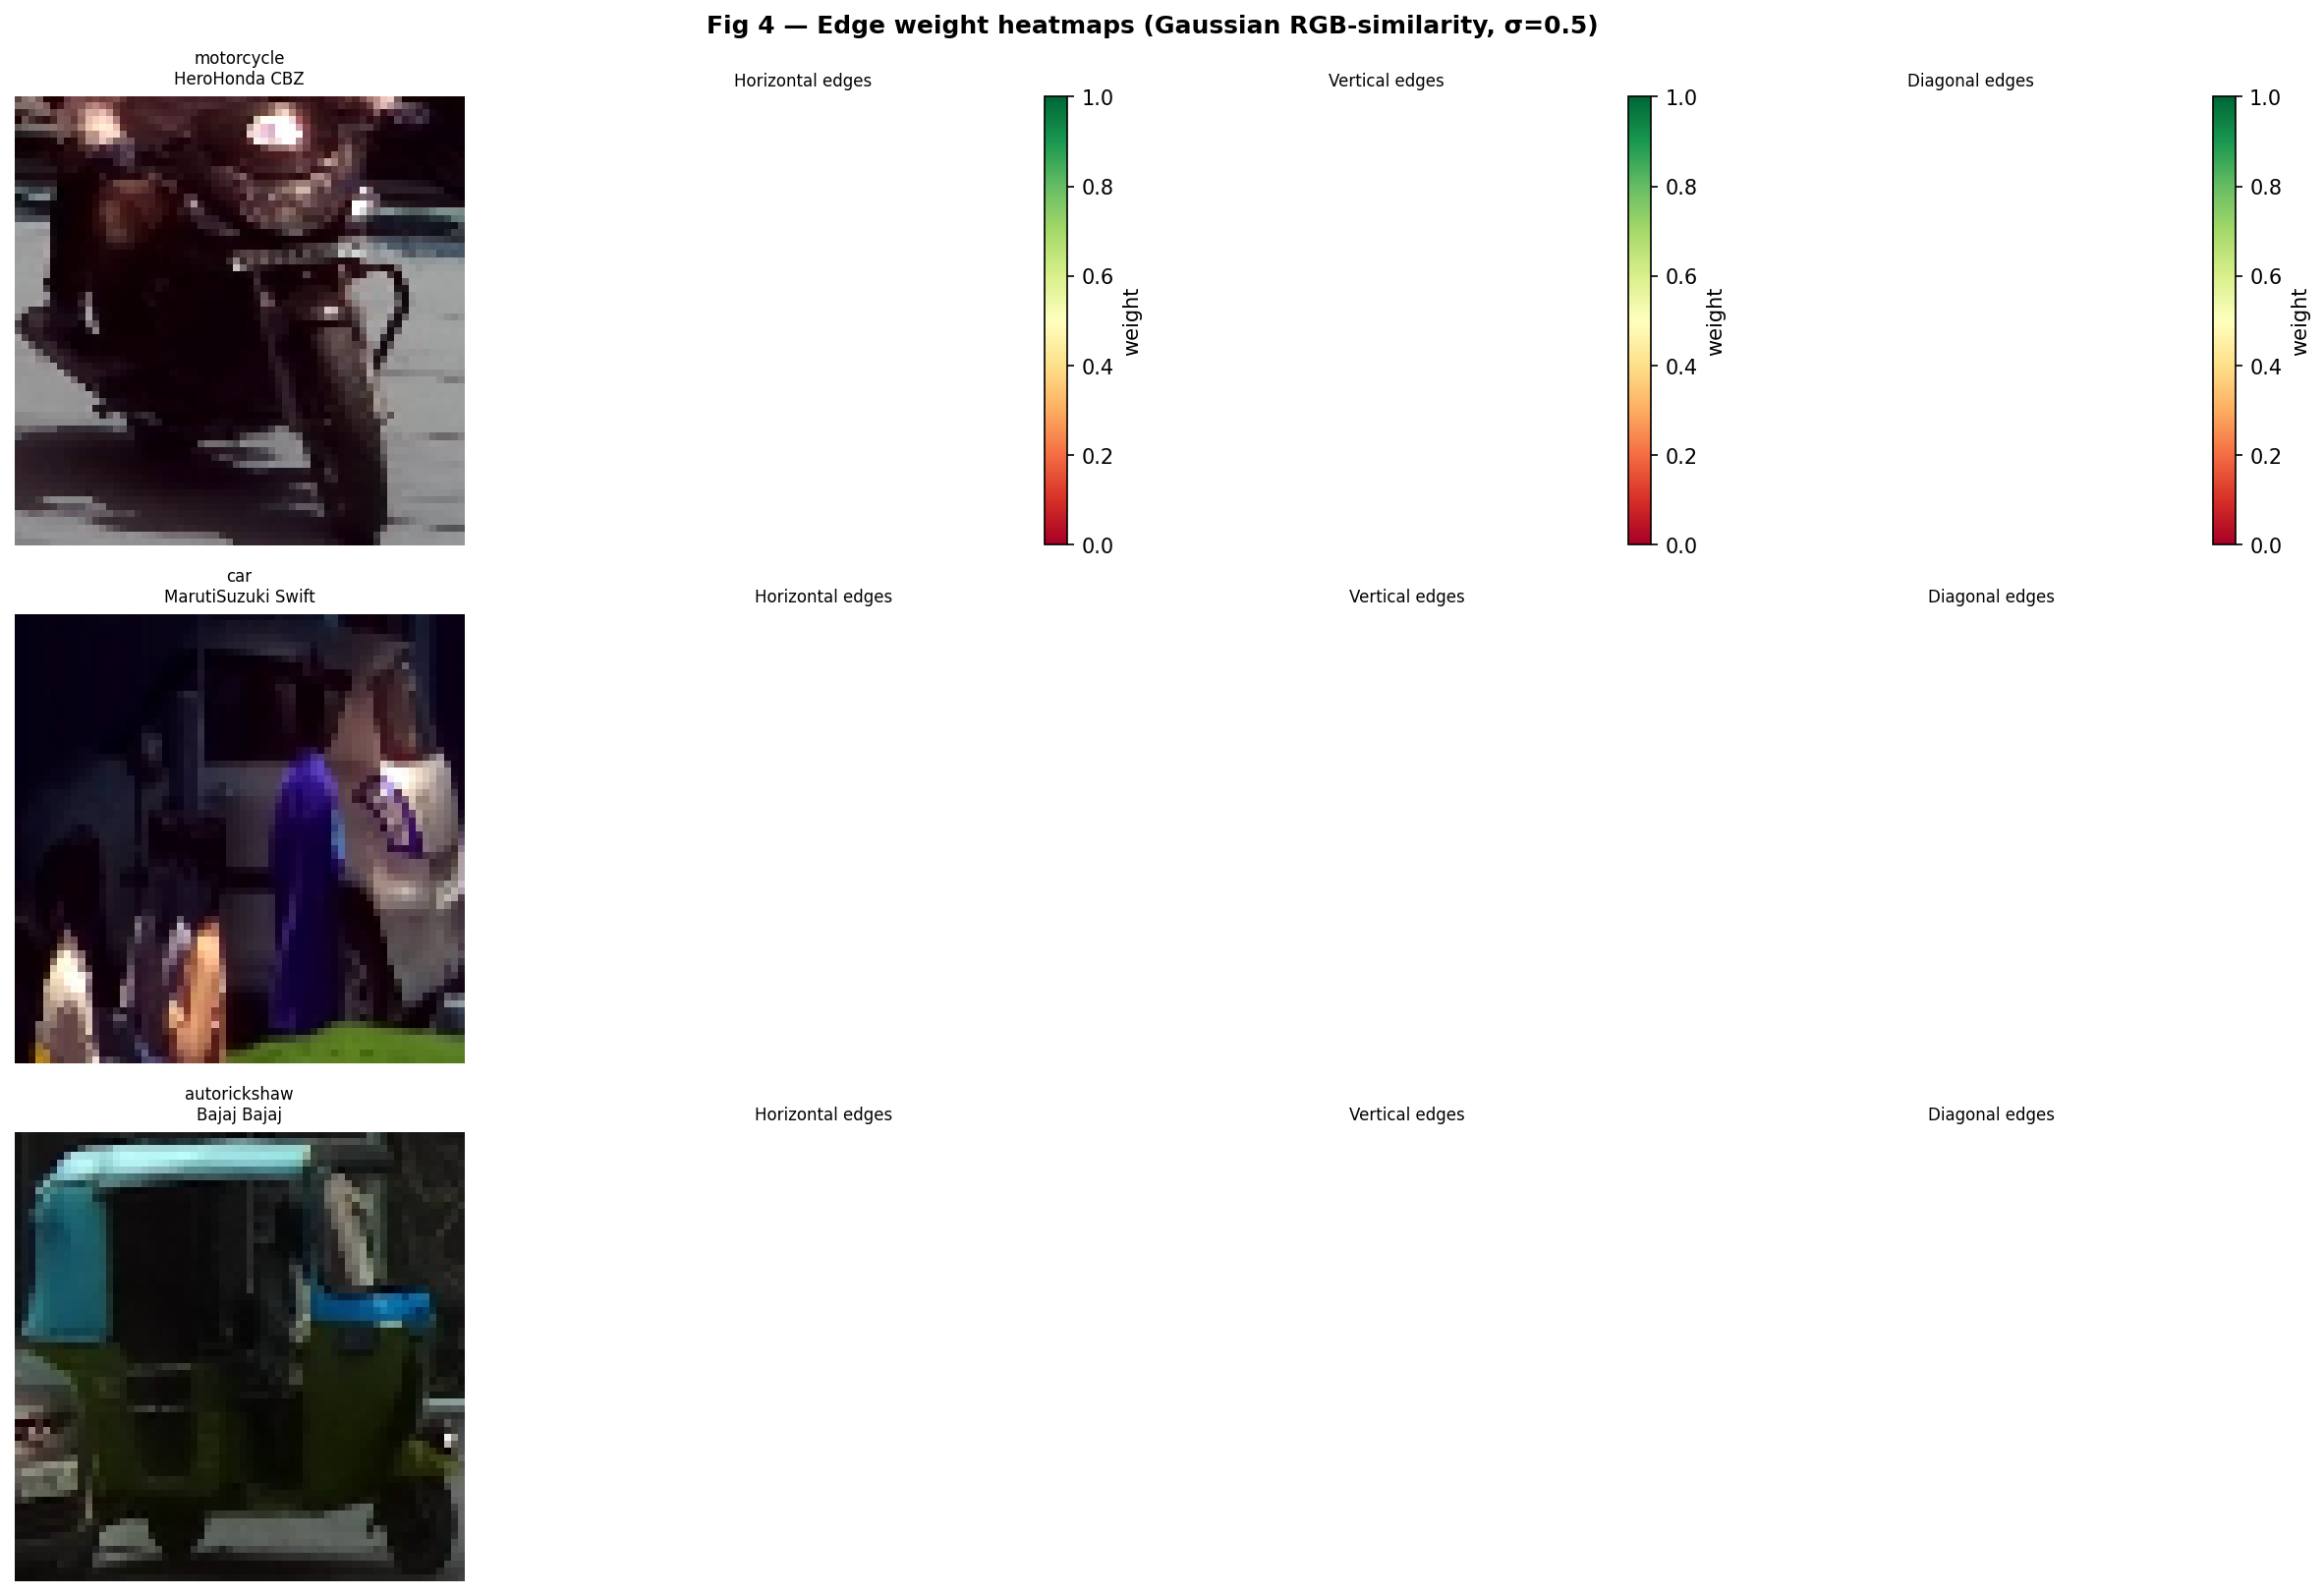

Saved fig4_edge_weights.png

Green = high similarity (smooth region), Red = low similarity (boundary/edge)


In [20]:
import scipy.sparse as sp

SIGMA = 0.5

# Load skeleton connectivity
skel_path = ROOT / 'master_grid_skeleton.npz'
if not skel_path.exists():
    skel_path = ROOT / 'master_grid_adj.npz'
coo = sp.load_npz(skel_path).tocoo()
src, dst = coo.row, coo.col

def compute_edge_weights(rgb_flat, sigma=0.5):
    diff = rgb_flat[src] - rgb_flat[dst]
    dist2 = (diff ** 2).sum(axis=1)
    return np.exp(-dist2 / (2 * sigma ** 2))

# Three contrasting crops: motorcycle (textured), car (uniform), autorickshaw (mixed)
demo_vehicles = [
    ('motorcycle', samples['motorcycle']),
    ('car',        samples['car']),
    ('autorickshaw', samples['autorickshaw']),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Fig 4 — Edge weight heatmaps (Gaussian RGB-similarity, σ=0.5)',
             fontsize=12, fontweight='bold')

for row_idx, (l1, row) in enumerate(demo_vehicles):
    vid, split = row.vehicle_id, row.split
    rgb_flat = np.load(ROOT / 'raw_features' / 'rgb' / split / f'{vid}.npy')
    weights  = compute_edge_weights(rgb_flat, SIGMA)

    # --- Col 0: RGB image ---
    img = (rgb_flat.reshape(64, 64, 3)[:, :, ::-1] * 255).clip(0,255).astype(np.uint8)
    axes[row_idx, 0].imshow(img, interpolation='nearest')
    axes[row_idx, 0].set_title(f'{l1}\n{row.L2} {row.L3}', fontsize=8)
    axes[row_idx, 0].axis('off')

    # --- Cols 1-3: mean edge weight for horizontal / vertical / diagonal edges ---
    weight_map_h  = np.full(64 * 64, np.nan)
    weight_map_v  = np.full(64 * 64, np.nan)
    weight_map_d  = np.full(64 * 64, np.nan)
    count_h = np.zeros(64 * 64)
    count_v = np.zeros(64 * 64)
    count_d = np.zeros(64 * 64)

    # categorise each edge by direction
    src_r, src_c = src // 64, src % 64
    dst_r, dst_c = dst // 64, dst % 64
    dr = dst_r - src_r
    dc = dst_c - src_c

    for map_, cnt, mask in [
        (weight_map_h, count_h, (dr == 0)),
        (weight_map_v, count_v, (dc == 0)),
        (weight_map_d, count_d, (np.abs(dr) == 1) & (np.abs(dc) == 1)),
    ]:
        idxs = np.where(mask)[0]
        np.add.at(cnt, src[idxs], 1)
        np.add.at(map_, src[idxs], np.where(np.isnan(map_[src[idxs]]), 0, map_[src[idxs]]) + weights[idxs])

    for col_idx, (wmap, cnt, label) in enumerate([
        (weight_map_h, count_h, 'Horizontal edges'),
        (weight_map_v, count_v, 'Vertical edges'),
        (weight_map_d, count_d, 'Diagonal edges'),
    ]):
        valid = cnt > 0
        grid = np.zeros(64 * 64)
        grid[valid] = wmap[valid] / cnt[valid]
        ax = axes[row_idx, col_idx + 1]
        im = ax.imshow(grid.reshape(64, 64), cmap='RdYlGn', vmin=0, vmax=1,
                       interpolation='nearest')
        ax.set_title(label, fontsize=8)
        ax.axis('off')
        if row_idx == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='weight')

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig4_edge_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig4_edge_weights.png')
print('\nGreen = high similarity (smooth region), Red = low similarity (boundary/edge)')

---
## Fig 5 — Edge weight histogram: smooth regions vs boundaries

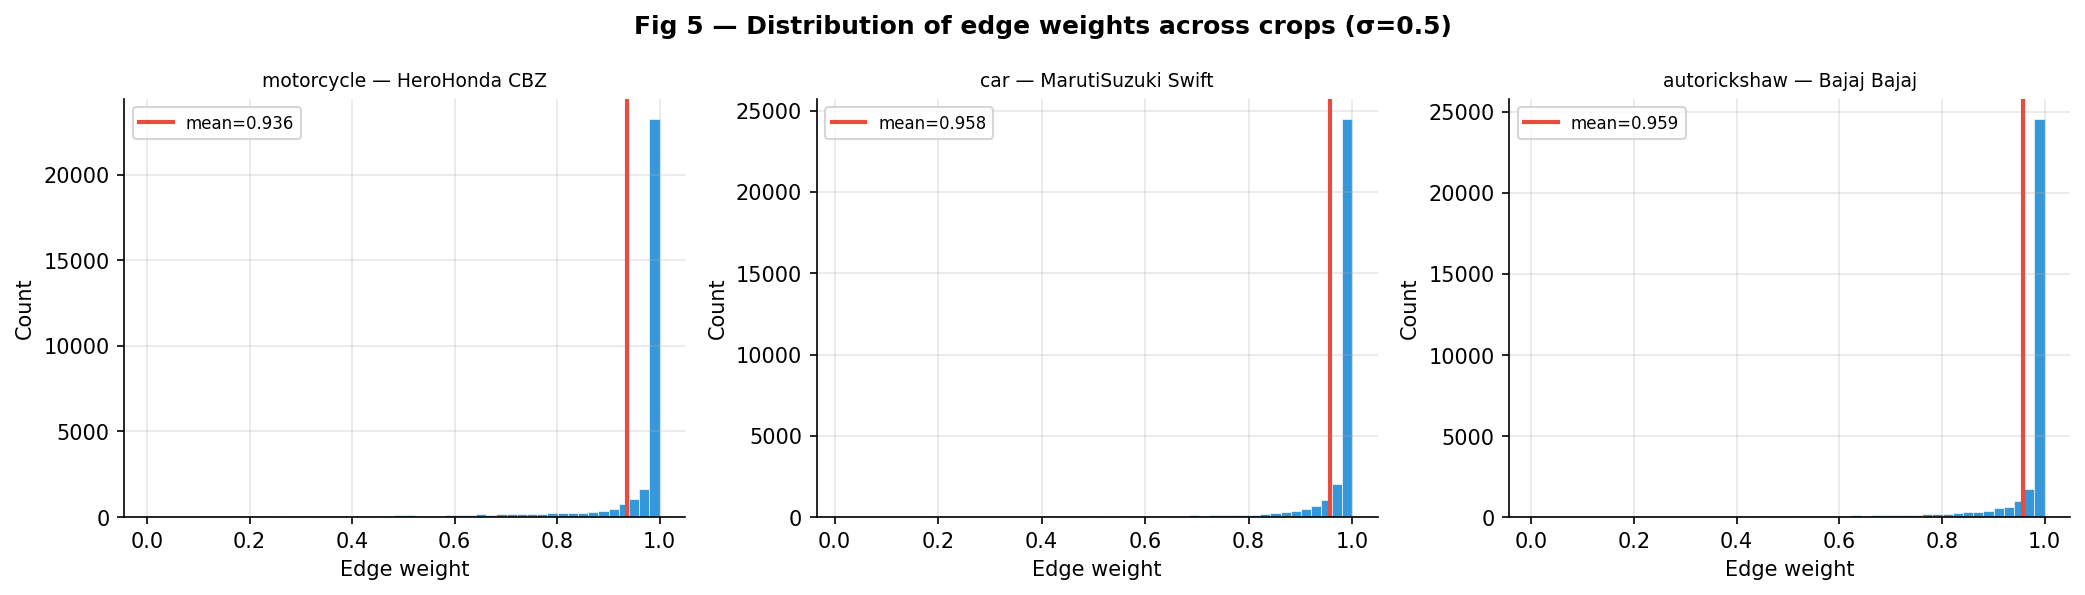

Saved fig5_edge_weight_hist.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Fig 5 — Distribution of edge weights across crops (σ=0.5)',
             fontsize=12, fontweight='bold')

for ax, (l1, row) in zip(axes, demo_vehicles):
    vid, split = row.vehicle_id, row.split
    rgb_flat = np.load(ROOT / 'raw_features' / 'rgb' / split / f'{vid}.npy')
    w = compute_edge_weights(rgb_flat, SIGMA)
    ax.hist(w, bins=50, color='#3498db', edgecolor='white', linewidth=0.3)
    ax.axvline(w.mean(), color='#e74c3c', lw=2, label=f'mean={w.mean():.3f}')
    ax.set_title(f'{l1} — {row.L2} {row.L3}', fontsize=9)
    ax.set_xlabel('Edge weight'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig5_edge_weight_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig5_edge_weight_hist.png')

---
## Fig 6 — Label hierarchy tree

Illustrates the three-level taxonomy for a selection of vehicle types.

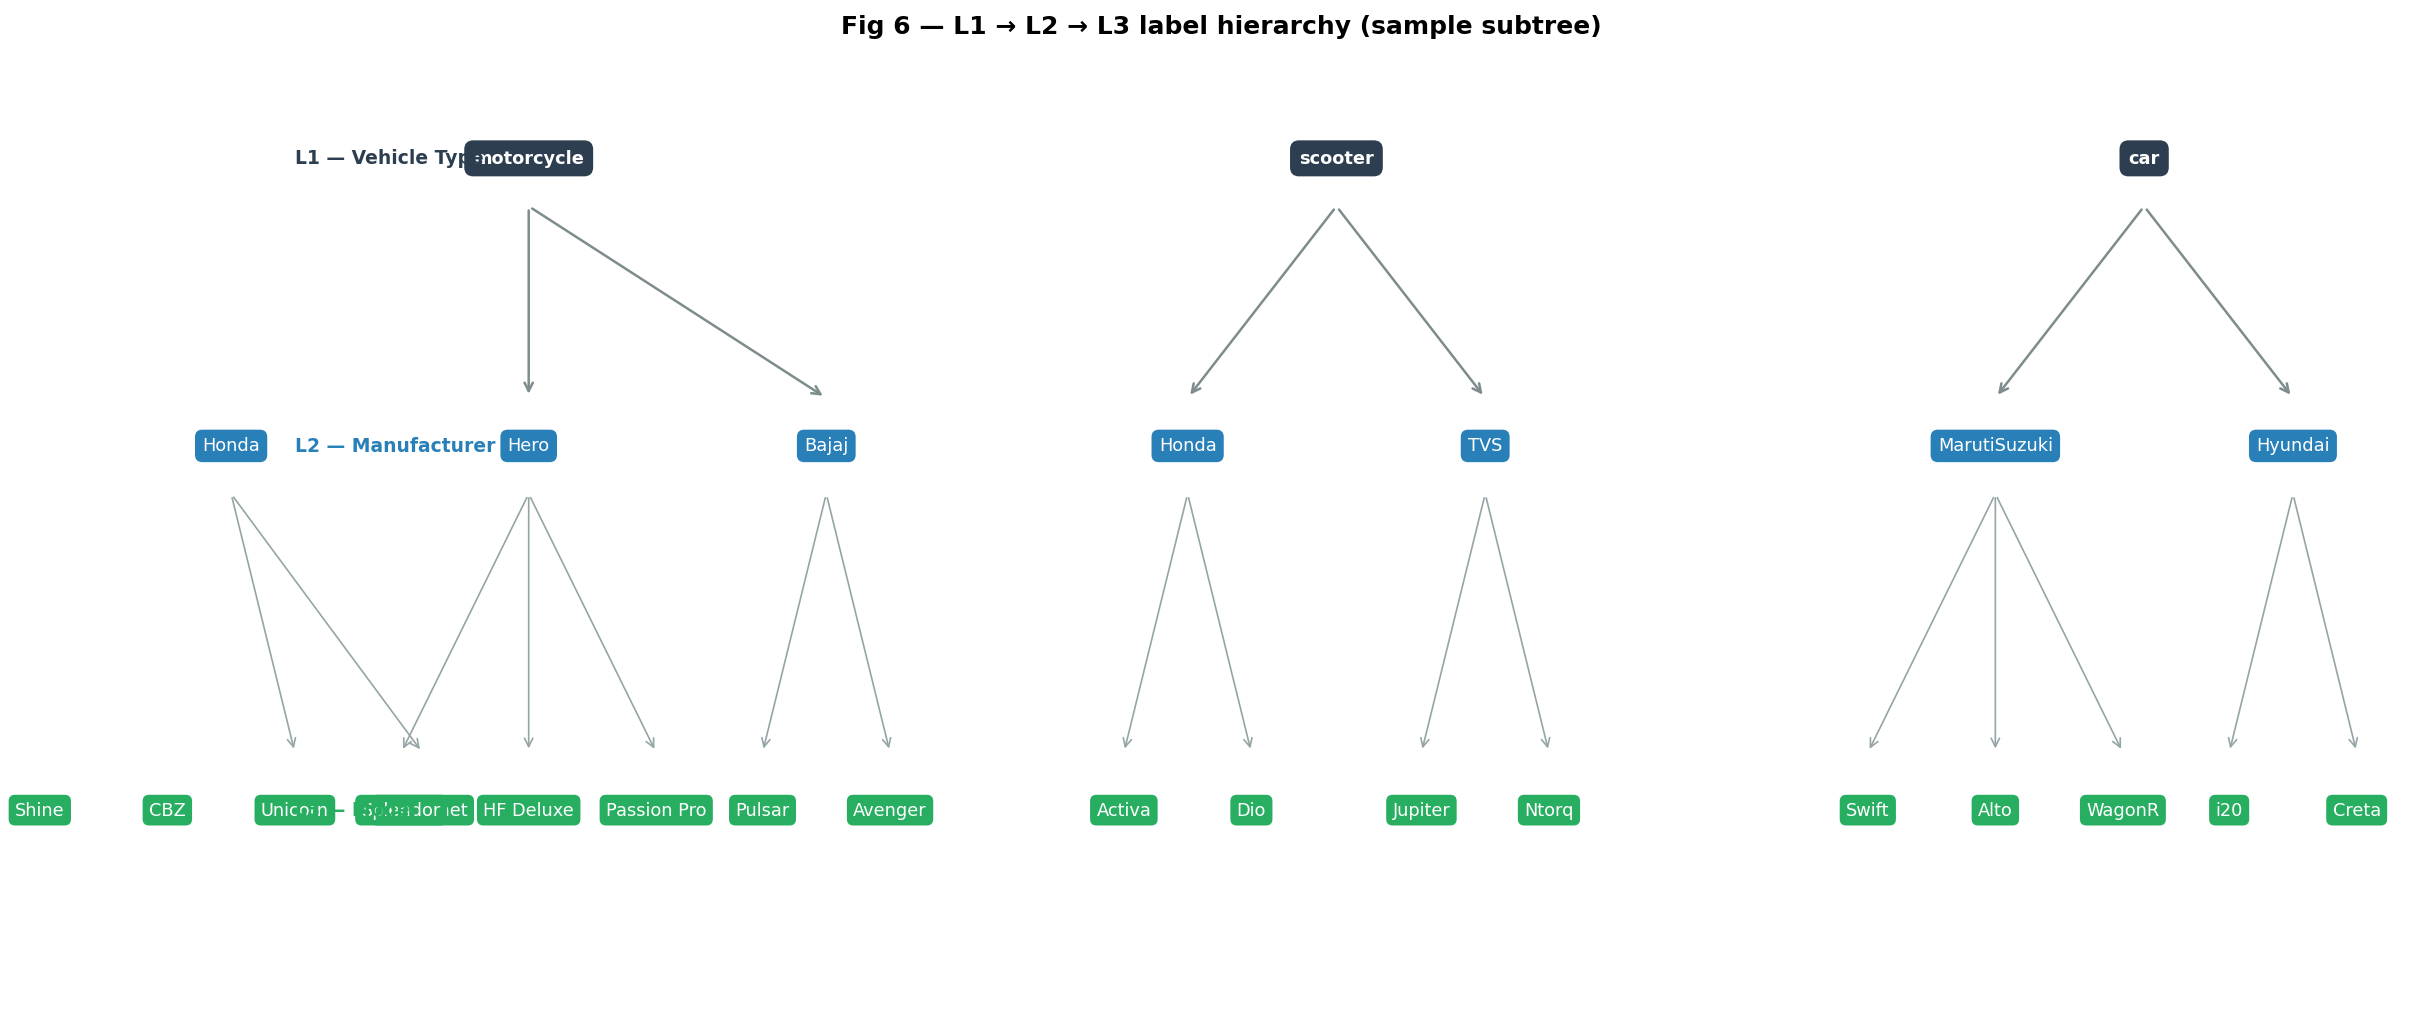

Saved fig6_label_hierarchy.png


In [22]:
# Build a sample subtree
tree = {
    'motorcycle': {
        'Honda': ['Shine', 'CBZ', 'Unicorn', 'CB Hornet'],
        'Hero':  ['Splendor', 'HF Deluxe', 'Passion Pro'],
        'Bajaj': ['Pulsar', 'Avenger'],
    },
    'scooter': {
        'Honda': ['Activa', 'Dio'],
        'TVS':   ['Jupiter', 'Ntorq'],
    },
    'car': {
        'MarutiSuzuki': ['Swift', 'Alto', 'WagonR'],
        'Hyundai':      ['i20', 'Creta'],
    },
}

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis('off')
fig.suptitle('Fig 6 — L1 → L2 → L3 label hierarchy (sample subtree)',
             fontsize=12, fontweight='bold')

COLORS = {'L1': '#2c3e50', 'L2': '#2980b9', 'L3': '#27ae60'}
NODE_STYLE = dict(ha='center', va='center', fontsize=8.5,
                  bbox=dict(boxstyle='round,pad=0.4', ec='#bdc3c7'))

l1_xs = np.linspace(0.12, 0.88, len(tree))
L1_Y, L2_Y, L3_Y = 0.90, 0.60, 0.22

for l1_i, (l1, l2_dict) in enumerate(tree.items()):
    x_l1 = l1_xs[l1_i]
    ax.text(x_l1, L1_Y, l1, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.45', fc=COLORS['L1'], ec=COLORS['L1']),
            **{k:v for k,v in NODE_STYLE.items() if k != 'bbox'})

    l2_keys = list(l2_dict.keys())
    spread = 0.14
    l2_xs = np.linspace(x_l1 - spread * (len(l2_keys)-1)/2,
                        x_l1 + spread * (len(l2_keys)-1)/2, len(l2_keys))

    for l2_i, (l2, l3_list) in enumerate(l2_dict.items()):
        x_l2 = l2_xs[l2_i]
        ax.annotate('', xy=(x_l2, L2_Y+0.05), xytext=(x_l1, L1_Y-0.05),
                    arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.2))
        ax.text(x_l2, L2_Y, l2, color='white',
                bbox=dict(boxstyle='round,pad=0.35', fc=COLORS['L2'], ec=COLORS['L2']),
                **{k:v for k,v in NODE_STYLE.items() if k != 'bbox'})

        n = len(l3_list)
        l3_xs = np.linspace(x_l2 - 0.06*(n-1)/2, x_l2 + 0.06*(n-1)/2, n)
        for l3_i, (l3, x_l3) in enumerate(zip(l3_list, l3_xs)):
            ax.annotate('', xy=(x_l3, L3_Y+0.06), xytext=(x_l2, L2_Y-0.05),
                        arrowprops=dict(arrowstyle='->', color='#95a5a6', lw=0.8))
            ax.text(x_l3, L3_Y, l3,
                    bbox=dict(boxstyle='round,pad=0.3', fc=COLORS['L3'], ec=COLORS['L3']),
                    color='white', **{k:v for k,v in NODE_STYLE.items() if k != 'bbox'})

for label, color, y in [('L1 — Vehicle Type', COLORS['L1'], L1_Y),
                         ('L2 — Manufacturer',  COLORS['L2'], L2_Y),
                         ('L3 — Model',         COLORS['L3'], L3_Y)]:
    ax.text(0.01, y, label, color=color, fontsize=9, fontweight='bold',
            transform=ax.transAxes, va='center')

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig6_label_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig6_label_hierarchy.png')

---
## Fig 7 — Long-tail analysis: class support distribution at L2 and L3

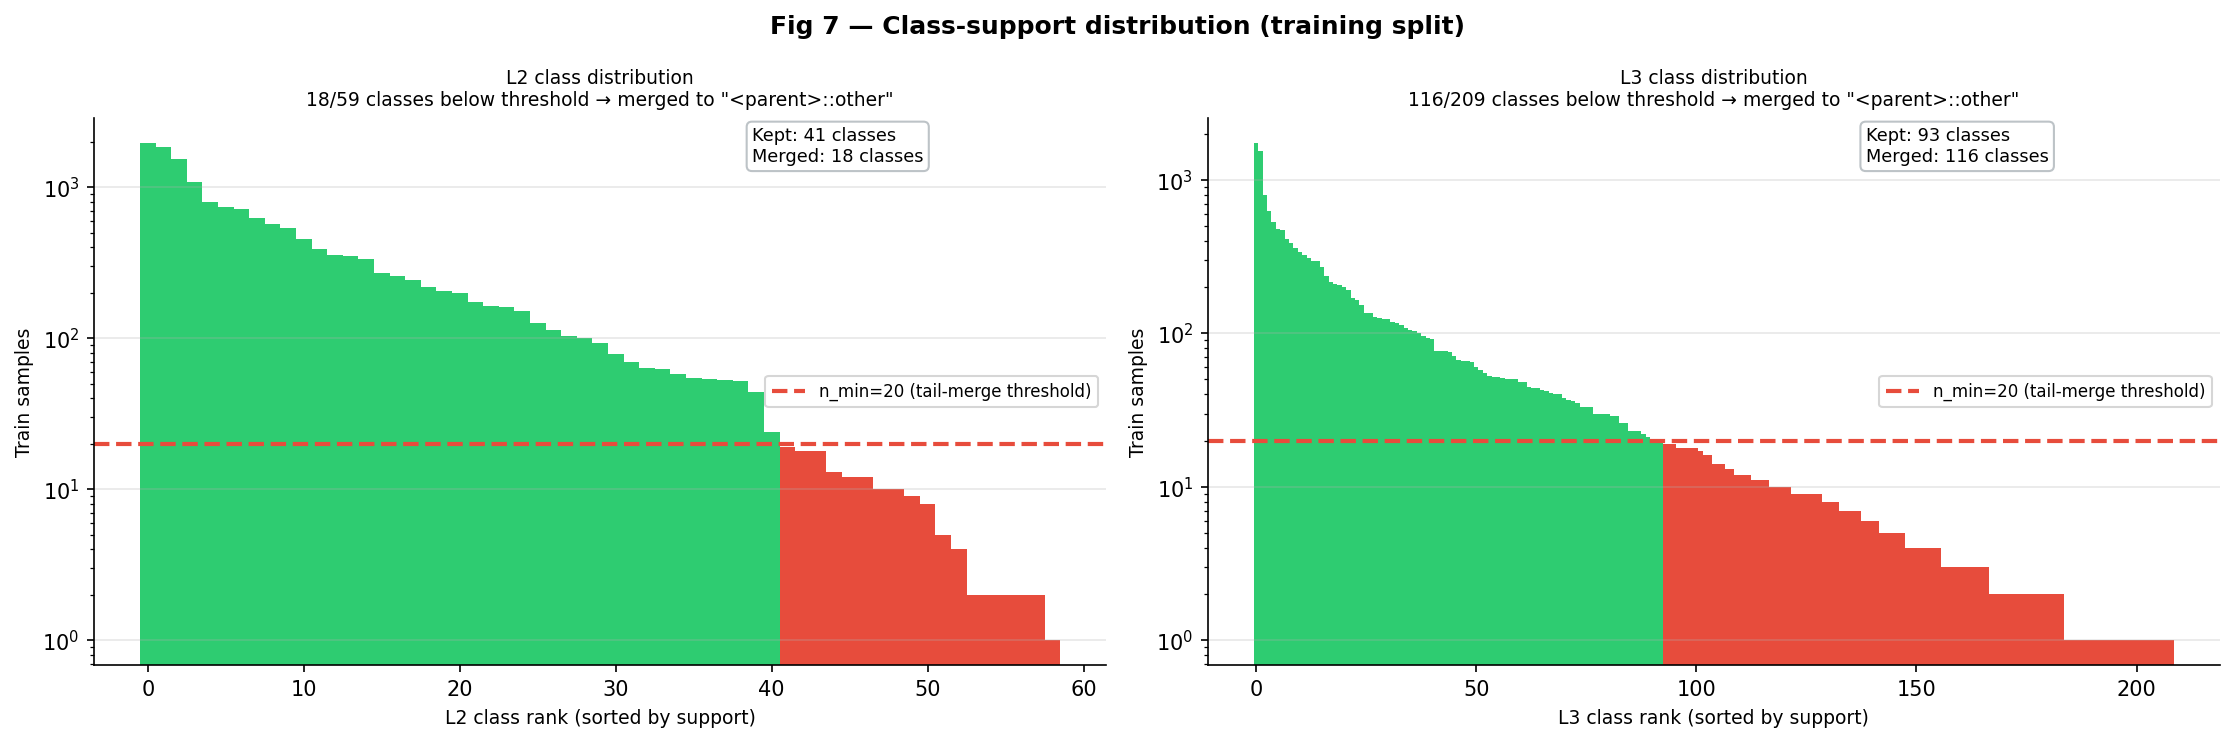

Saved fig7_class_distribution.png


In [23]:
train_df = metadata[metadata.split == 'train']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Fig 7 — Class-support distribution (training split)',
             fontsize=12, fontweight='bold')

N_MIN = 20

for ax, level, label_col in zip(axes, ['L2', 'L3'], ['L2', 'L3']):
    if level == 'L2':
        combined = (train_df.L1 + '::' + train_df.L2).values
    else:
        combined = (train_df.L1 + '::' + train_df.L2 + '::' + train_df.L3).values

    counts = sorted(Counter(combined).values(), reverse=True)
    colors = ['#2ecc71' if c >= N_MIN else '#e74c3c' for c in counts]

    ax.bar(range(len(counts)), counts, color=colors, width=1.0, edgecolor='none')
    ax.axhline(N_MIN, color='#e74c3c', lw=2, ls='--', label=f'n_min={N_MIN} (tail-merge threshold)')
    ax.set_xlabel(f'{level} class rank (sorted by support)', fontsize=9)
    ax.set_ylabel('Train samples', fontsize=9)
    ax.set_title(f'{level} class distribution\n'
                 f'{sum(c < N_MIN for c in counts)}/{len(counts)} classes below threshold → merged to "<parent>::other"',
                 fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
    ax.set_yscale('log')

    kept = sum(c >= N_MIN for c in counts)
    ax.text(0.65, 0.92, f'Kept: {kept} classes\nMerged: {len(counts)-kept} classes',
            transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle='round', fc='white', ec='#bdc3c7'))

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig7_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig7_class_distribution.png')

---
## Fig 8 — Results comparison: Top-1 / Top-3 / Top-5 bar chart

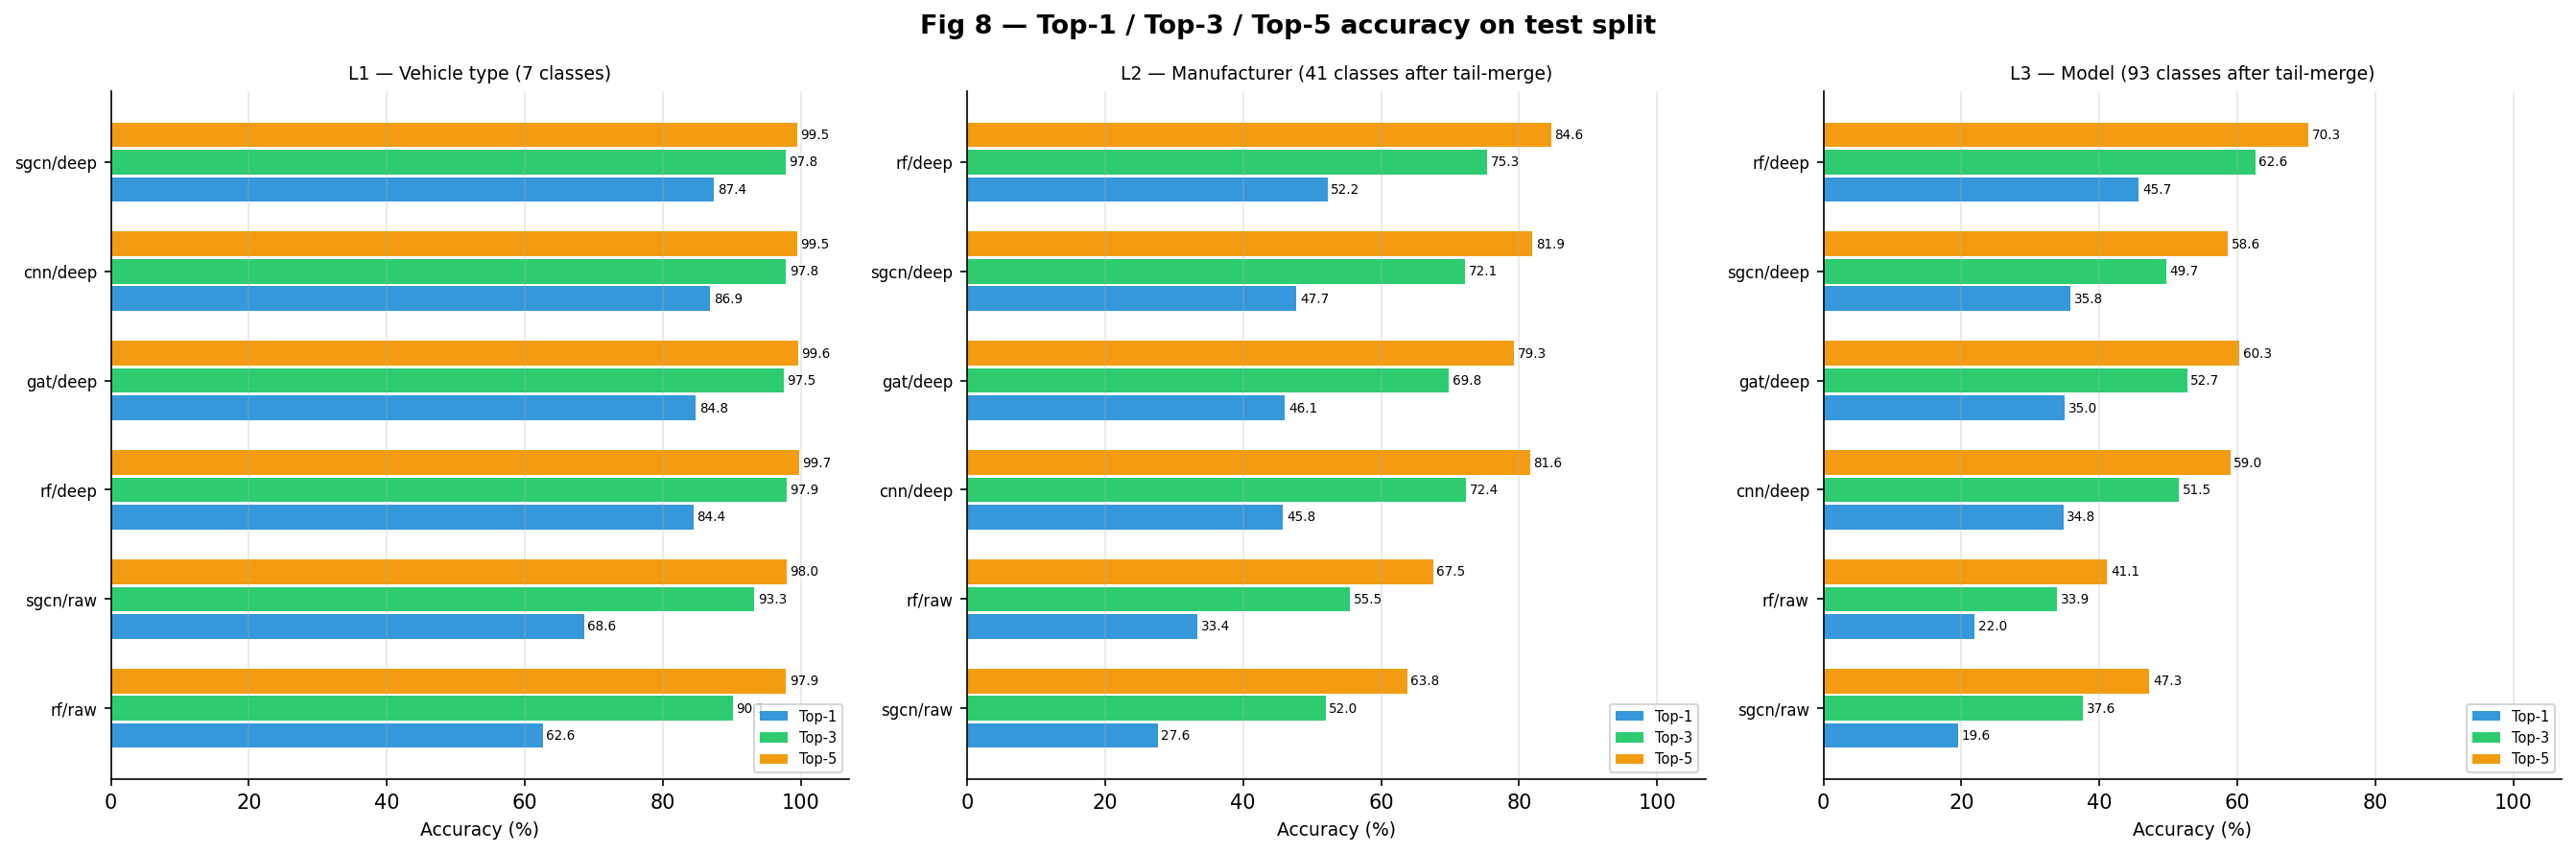

Saved fig8_topk_bar.png


In [24]:
df = pd.read_csv(RESULTS / 'comparison_table.csv')
df['label'] = df.apply(lambda r: f"{r['method']}/{r['features']}", axis=1)
df['top1']  = df['top1'].astype(float) * 100
df['top3']  = df['top3'].astype(float) * 100
df['top5']  = df['top5'].astype(float) * 100

LEVEL_TITLES = {
    'L1': 'L1 — Vehicle type (7 classes)',
    'L2': 'L2 — Manufacturer (41 classes after tail-merge)',
    'L3': 'L3 — Model (93 classes after tail-merge)',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Fig 8 — Top-1 / Top-3 / Top-5 accuracy on test split',
             fontsize=13, fontweight='bold')

for ax, level in zip(axes, ['L1', 'L2', 'L3']):
    sub = df[df['level'] == level].copy().sort_values('top1', ascending=True)
    y   = np.arange(len(sub))
    h   = 0.25

    bars1 = ax.barh(y - h, sub['top1'], h*0.9, label='Top-1', color='#3498db')
    bars3 = ax.barh(y,     sub['top3'], h*0.9, label='Top-3', color='#2ecc71')
    bars5 = ax.barh(y + h, sub['top5'], h*0.9, label='Top-5', color='#f39c12')

    for bars in (bars1, bars3, bars5):
        for bar in bars:
            w = bar.get_width()
            ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{w:.1f}', va='center', ha='left', fontsize=6.5)

    ax.set_yticks(y)
    ax.set_yticklabels(sub['label'], fontsize=8)
    ax.set_xlabel('Accuracy (%)', fontsize=9)
    ax.set_title(LEVEL_TITLES[level], fontsize=9, pad=6)
    ax.set_xlim(0, 107)
    ax.grid(alpha=0.3, axis='x')
    ax.legend(fontsize=7, loc='lower right')

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig8_topk_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig8_topk_bar.png')

---
## Fig 9 — Macro-F1 performance heatmap: method × level

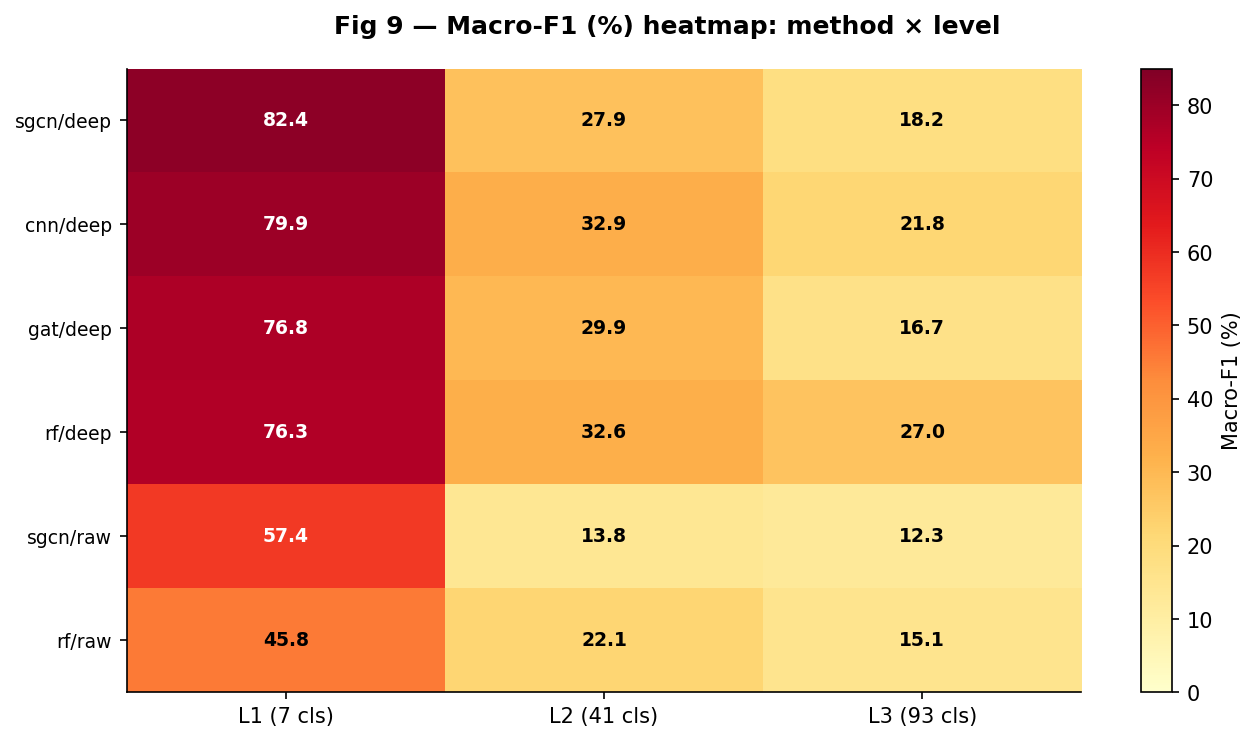

Saved fig9_macro_f1_heatmap.png


In [25]:
df_pivot = df.pivot_table(
    index='label', columns='level',
    values='macro_f1', aggfunc='first'
).reindex(columns=['L1','L2','L3']).astype(float) * 100

# Sort by L1 macro-F1 descending
df_pivot = df_pivot.sort_values('L1', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Fig 9 — Macro-F1 (%) heatmap: method × level', fontsize=12, fontweight='bold')

im = ax.imshow(df_pivot.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=85)
plt.colorbar(im, ax=ax, label='Macro-F1 (%)')

ax.set_xticks(range(3)); ax.set_xticklabels(['L1 (7 cls)', 'L2 (41 cls)', 'L3 (93 cls)'], fontsize=10)
ax.set_yticks(range(len(df_pivot))); ax.set_yticklabels(df_pivot.index, fontsize=9)

for r in range(len(df_pivot)):
    for c in range(3):
        val = df_pivot.values[r, c]
        color = 'white' if val > 50 else 'black'
        ax.text(c, r, f'{val:.1f}', ha='center', va='center', fontsize=9,
                fontweight='bold', color=color)

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig9_macro_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig9_macro_f1_heatmap.png')

---
## Fig 10 — Deep vs Raw features: side-by-side accuracy gain

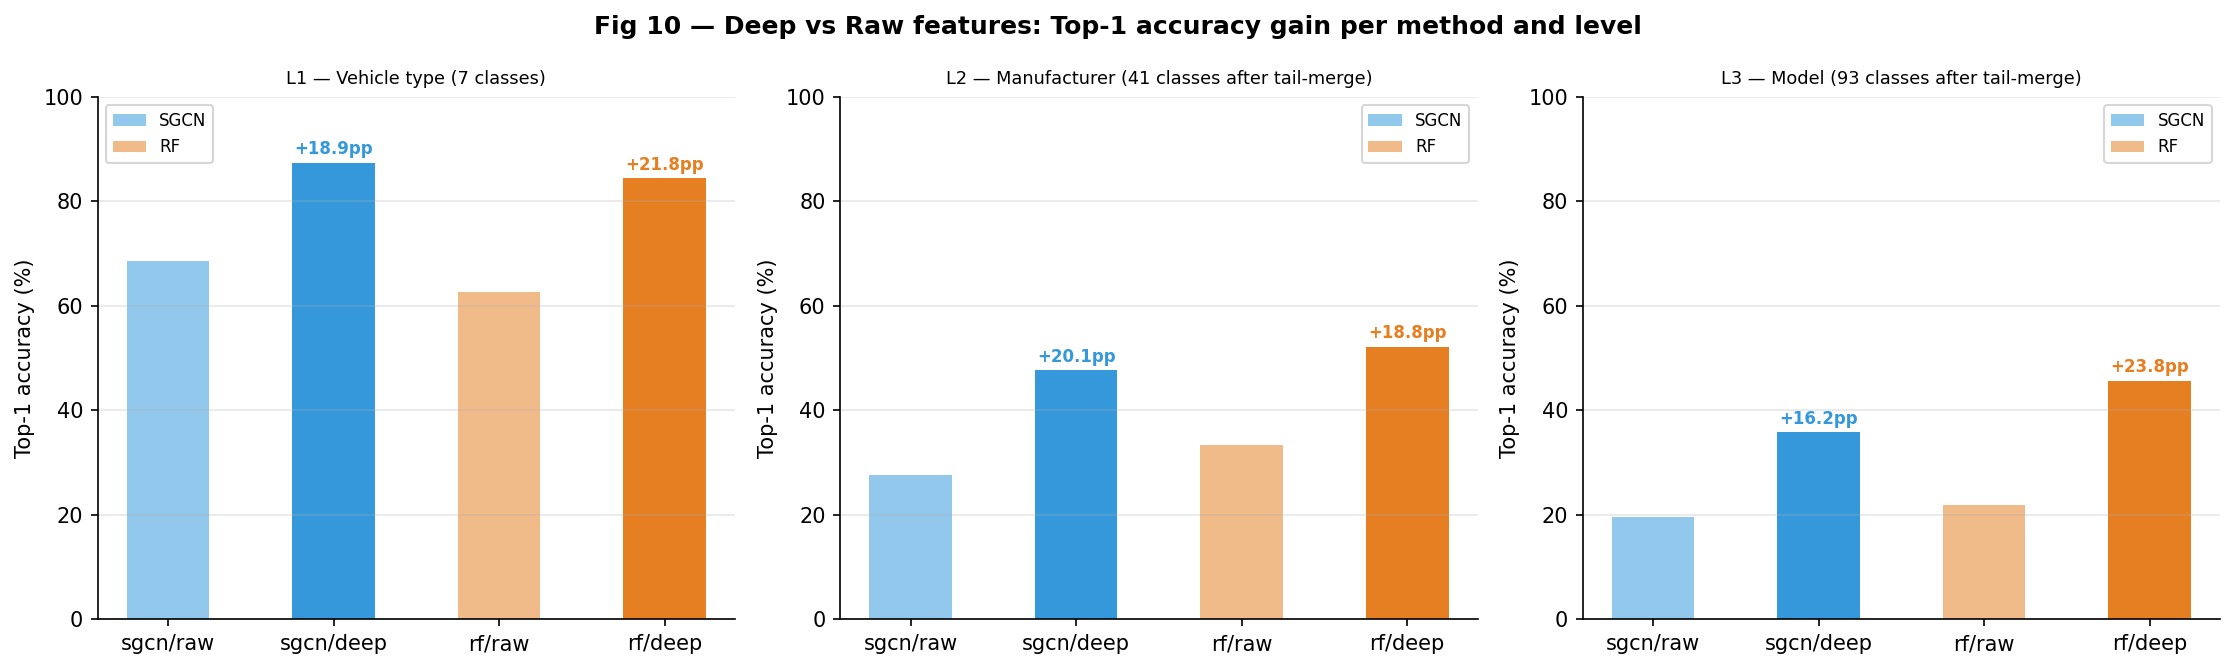

Saved fig10_deep_vs_raw.png


In [26]:
# Methods that have both raw and deep runs
paired = df[df['method'].isin(['sgcn', 'rf'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Fig 10 — Deep vs Raw features: Top-1 accuracy gain per method and level',
             fontsize=12, fontweight='bold')

for ax, level in zip(axes, ['L1', 'L2', 'L3']):
    sub = paired[paired.level == level]
    for method, color in [('sgcn', '#3498db'), ('rf', '#e67e22')]:
        m = sub[sub.method == method].set_index('features')['top1']
        if 'raw' in m.index and 'deep' in m.index:
            ax.bar([f'{method}/raw', f'{method}/deep'],
                   [m['raw'], m['deep']], color=[color+'88', color], width=0.5,
                   label=method.upper())
            ax.annotate(f'+{m["deep"]-m["raw"]:.1f}pp',
                        xy=(1 if method=='sgcn' else 3, m['deep']),
                        xytext=(0, 4), textcoords='offset points',
                        ha='center', fontsize=8, color=color, fontweight='bold')

    ax.set_title(LEVEL_TITLES[level], fontsize=8.5)
    ax.set_ylabel('Top-1 accuracy (%)'); ax.set_ylim(0, 100)
    ax.grid(alpha=0.3, axis='y'); ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig10_deep_vs_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig10_deep_vs_raw.png')

---
## Fig 11 — Learning curves: validation accuracy overlay per level

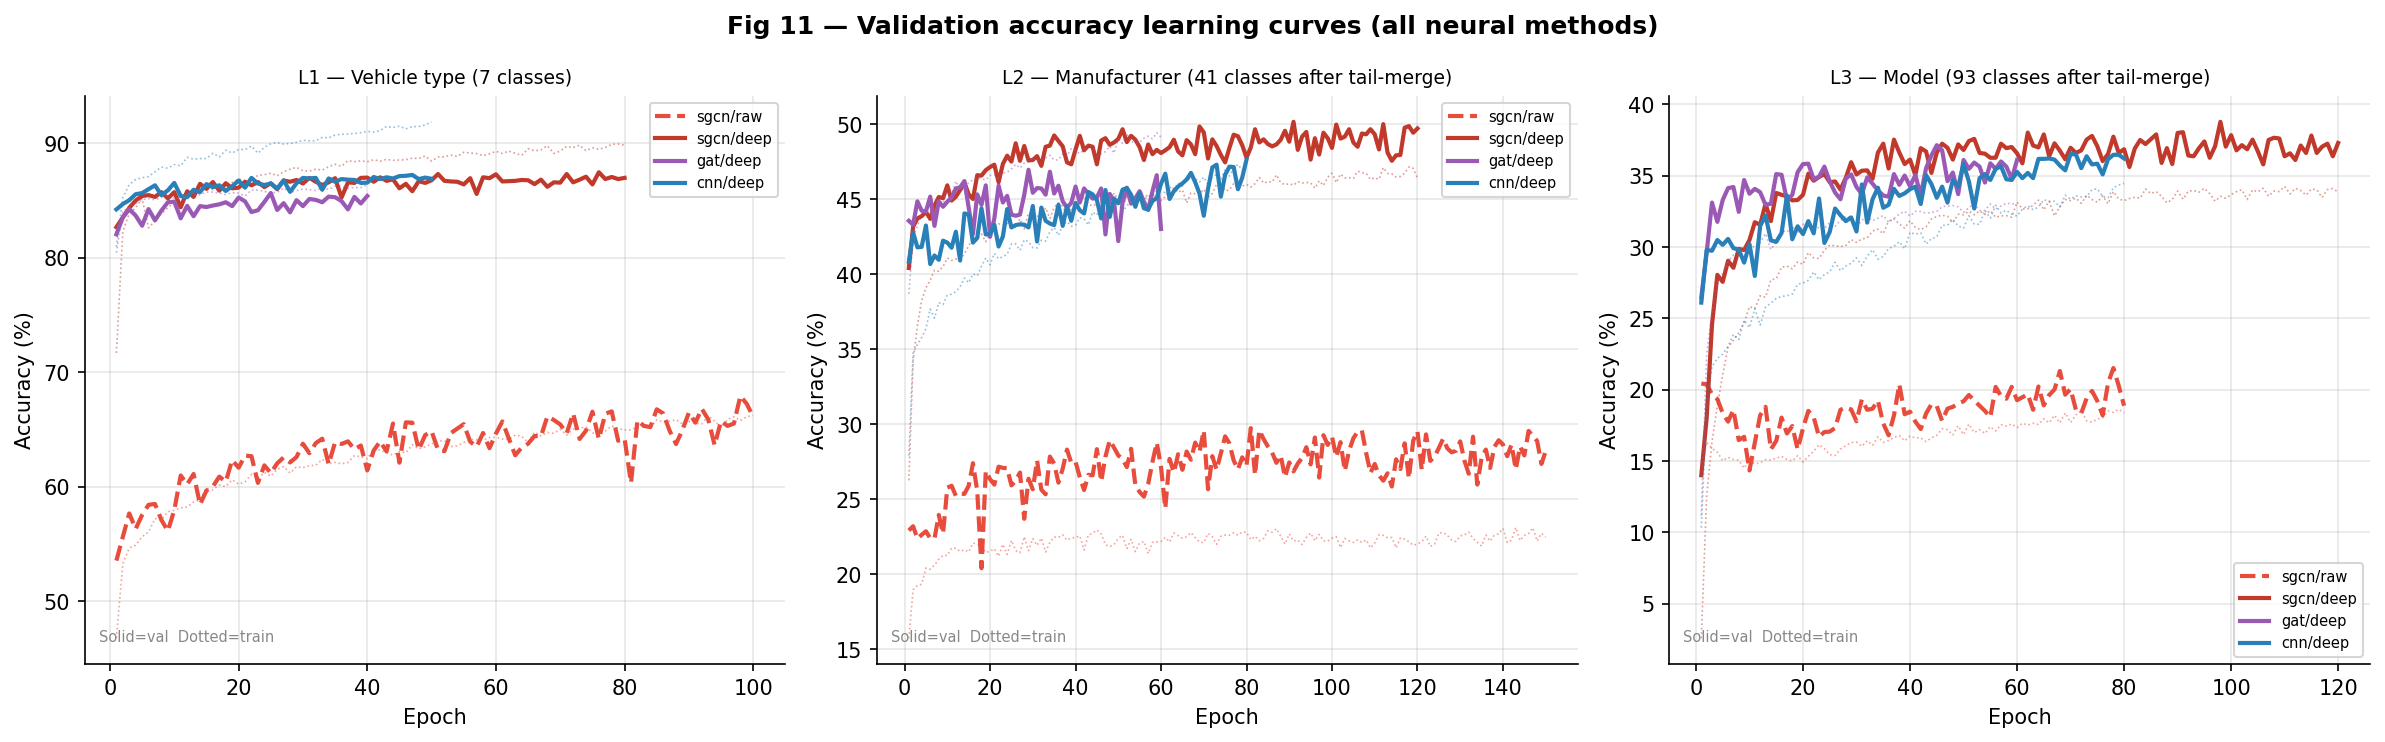

Saved fig11_learning_curves.png


In [27]:
METHOD_COLORS = {
    'sgcn/raw':  '#e74c3c',
    'sgcn/deep': '#c0392b',
    'gat/deep':  '#9b59b6',
    'cnn/deep':  '#2980b9',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig 11 — Validation accuracy learning curves (all neural methods)',
             fontsize=12, fontweight='bold')

for ax, level in zip(axes, ['L1', 'L2', 'L3']):
    found = []
    for method in ['sgcn', 'gat', 'cnn']:
        for features in ['raw', 'deep']:
            path = CKPT / method / features / f'{level}_all' / 'metrics.json'
            if not path.exists():
                continue
            with open(path) as f:
                payload = json.load(f)
            h = payload.get('history', {})
            if not h or not h.get('val_acc'):
                continue
            key   = f'{method}/{features}'
            color = METHOD_COLORS.get(key, '#7f8c8d')
            ls    = '--' if features == 'raw' else '-'
            ax.plot(h['epoch'], [v*100 for v in h['val_acc']],
                    label=key, color=color, lw=2, ls=ls)
            ax.plot(h['epoch'], [v*100 for v in h['train_acc']],
                    color=color, lw=0.8, ls=':', alpha=0.5)
            found.append(key)

    ax.set_title(LEVEL_TITLES[level], fontsize=9)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=1)
    ax.text(0.02, 0.04, 'Solid=val  Dotted=train',
            transform=ax.transAxes, fontsize=7, color='#888')

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig11_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig11_learning_curves.png')

---
## Fig 12 — Pipeline architecture diagram

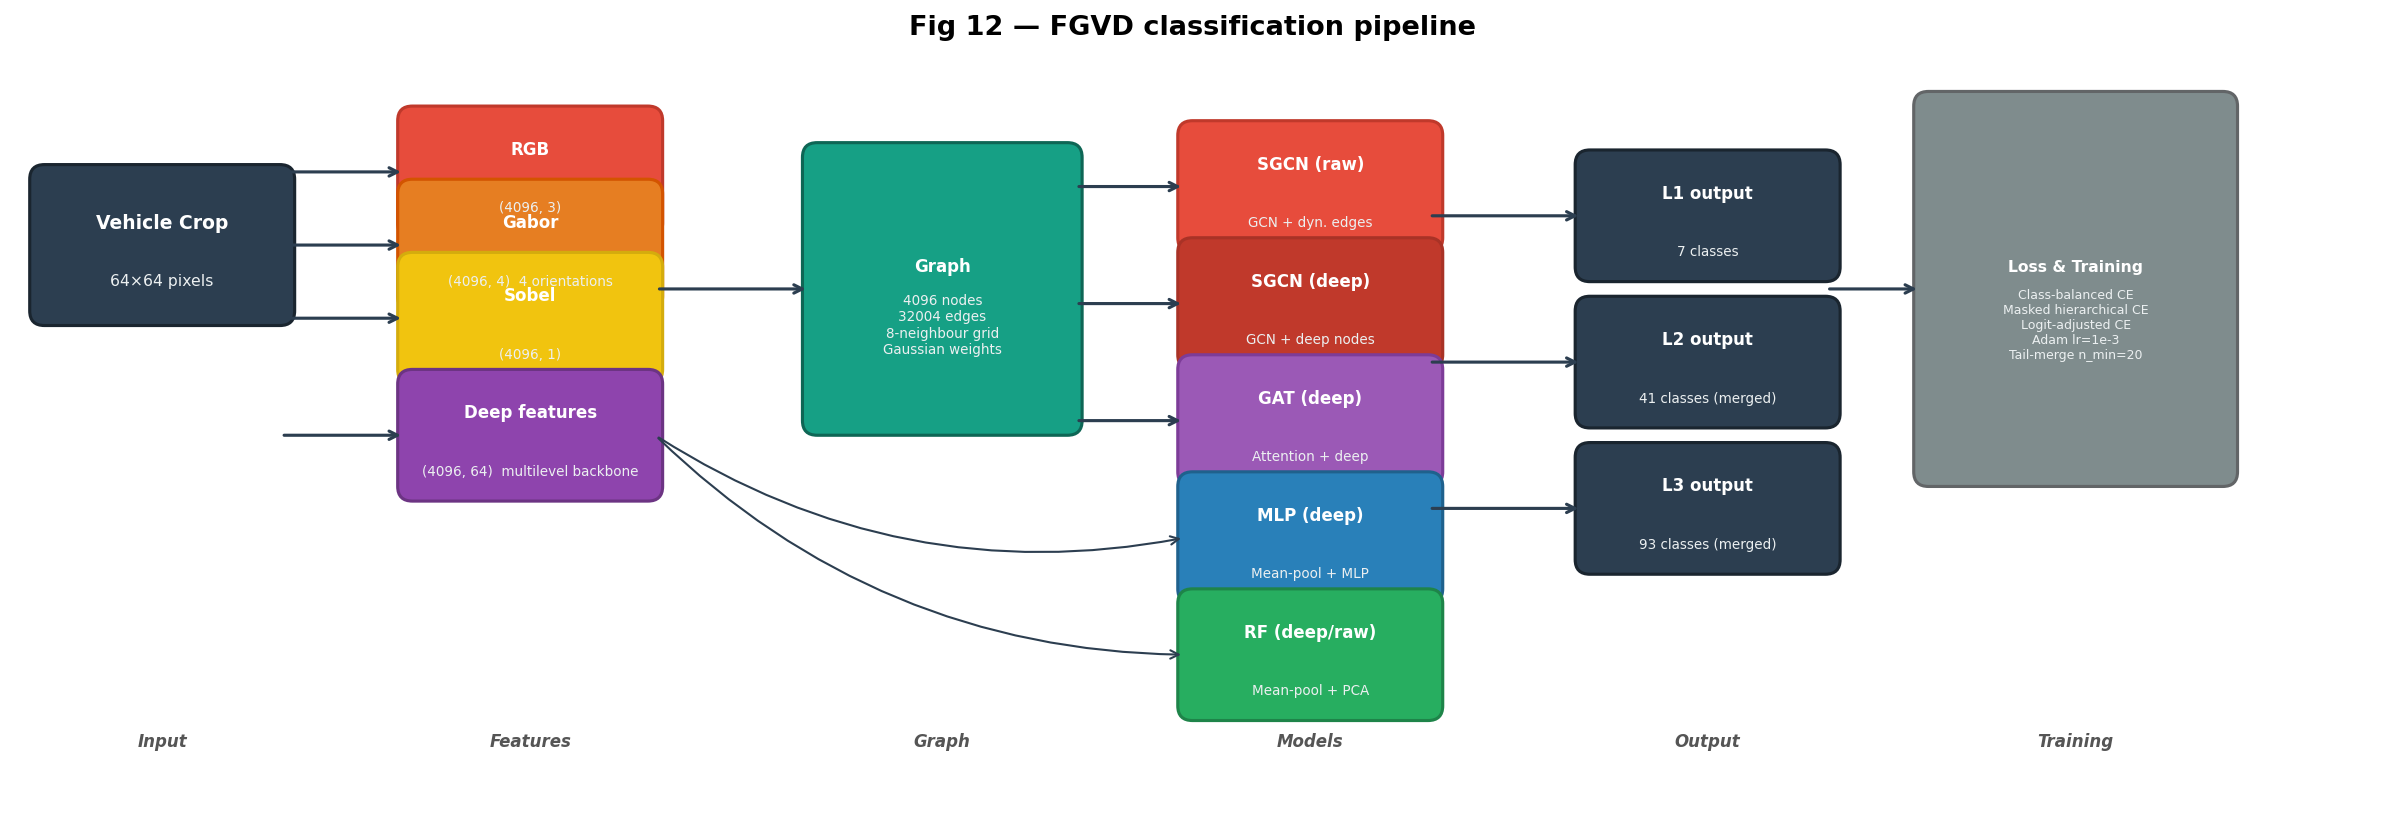

Saved fig12_pipeline.png


In [28]:
fig, ax = plt.subplots(figsize=(16, 5.5))
ax.axis('off')
ax.set_xlim(0, 16); ax.set_ylim(0, 5)
fig.suptitle('Fig 12 — FGVD classification pipeline', fontsize=13, fontweight='bold')

def draw_box(ax, cx, cy, w, h, label, sublabel='', fc='#3498db', ec='#2980b9', fs=9):
    rect = mpatches.FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                                    boxstyle='round,pad=0.1',
                                    fc=fc, ec=ec, lw=1.5)
    ax.add_patch(rect)
    ax.text(cx, cy + (0.15 if sublabel else 0), label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color='white')
    if sublabel:
        ax.text(cx, cy - 0.25, sublabel, ha='center', va='center',
                fontsize=fs - 1.5, color='#ecf0f1')

def arrow(ax, x1, x2, y, **kw):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5, **kw))

Y_TOP, Y_MID, Y_BOT = 3.8, 2.5, 1.2

# Step 1: input image
draw_box(ax, 1.0, Y_TOP, 1.6, 0.9, 'Vehicle Crop', '64×64 pixels', fc='#2c3e50', ec='#1a252f')

# Step 2: feature extraction
draw_box(ax, 3.5, 4.3, 1.6, 0.7, 'RGB', '(4096, 3)', fc='#e74c3c', ec='#c0392b', fs=8)
draw_box(ax, 3.5, 3.8, 1.6, 0.7, 'Gabor', '(4096, 4)  4 orientations', fc='#e67e22', ec='#d35400', fs=8)
draw_box(ax, 3.5, 3.3, 1.6, 0.7, 'Sobel', '(4096, 1)', fc='#f1c40f', ec='#d4ac0d', fs=8)
draw_box(ax, 3.5, 2.5, 1.6, 0.7, 'Deep features', '(4096, 64)  multilevel backbone', fc='#8e44ad', ec='#6c3483', fs=8)

for y_f in [4.3, 3.8, 3.3, 2.5]:
    arrow(ax, 1.8, 2.65, y_f)

# Step 3: graph construction
draw_box(ax, 6.3, 3.5, 1.7, 1.8, 'Graph', '4096 nodes\n32004 edges\n8-neighbour grid\nGaussian weights',
         fc='#16a085', ec='#0e6655', fs=8)
arrow(ax, 4.35, 5.4, 3.5)

# Step 4: model
draw_box(ax, 8.8, 4.2, 1.6, 0.7, 'SGCN (raw)', 'GCN + dyn. edges', fc='#e74c3c', ec='#c0392b', fs=8)
draw_box(ax, 8.8, 3.4, 1.6, 0.7, 'SGCN (deep)', 'GCN + deep nodes', fc='#c0392b', ec='#a93226', fs=8)
draw_box(ax, 8.8, 2.6, 1.6, 0.7, 'GAT (deep)', 'Attention + deep', fc='#9b59b6', ec='#7d3c98', fs=8)
draw_box(ax, 8.8, 1.8, 1.6, 0.7, 'MLP (deep)', 'Mean-pool + MLP', fc='#2980b9', ec='#1f618d', fs=8)
draw_box(ax, 8.8, 1.0, 1.6, 0.7, 'RF (deep/raw)', 'Mean-pool + PCA', fc='#27ae60', ec='#1e8449', fs=8)

for y_m in [4.2, 3.4, 2.6]:
    arrow(ax, 7.2, 7.95, y_m)
for y_m in [1.8, 1.0]:
    ax.annotate('', xy=(7.95, y_m), xytext=(4.35, 2.5),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.0, connectionstyle='arc3,rad=0.2'))

# Step 5: output levels
draw_box(ax, 11.5, 4.0, 1.6, 0.7, 'L1 output', '7 classes', fc='#2c3e50', ec='#1a252f', fs=8)
draw_box(ax, 11.5, 3.0, 1.6, 0.7, 'L2 output', '41 classes (merged)', fc='#2c3e50', ec='#1a252f', fs=8)
draw_box(ax, 11.5, 2.0, 1.6, 0.7, 'L3 output', '93 classes (merged)', fc='#2c3e50', ec='#1a252f', fs=8)

for y_o in [4.0, 3.0, 2.0]:
    arrow(ax, 9.6, 10.65, y_o)

# Step 6: loss
draw_box(ax, 14.0, 3.5, 2.0, 2.5, 'Loss & Training',
         'Class-balanced CE\nMasked hierarchical CE\nLogit-adjusted CE\nAdam lr=1e-3\nTail-merge n_min=20',
         fc='#7f8c8d', ec='#626567', fs=7.5)
arrow(ax, 12.3, 12.95, 3.5)

# Stage labels
for x, lbl in [(1.0,'Input'), (3.5,'Features'), (6.3,'Graph'), (8.8,'Models'), (11.5,'Output'), (14.0,'Training')]:
    ax.text(x, 0.4, lbl, ha='center', va='center', fontsize=8, color='#555',
            fontweight='bold', style='italic')

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig12_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig12_pipeline.png')

---
## Fig 13 — Tail-merge coverage: what fraction of test samples are predicted vs routed to 'other'

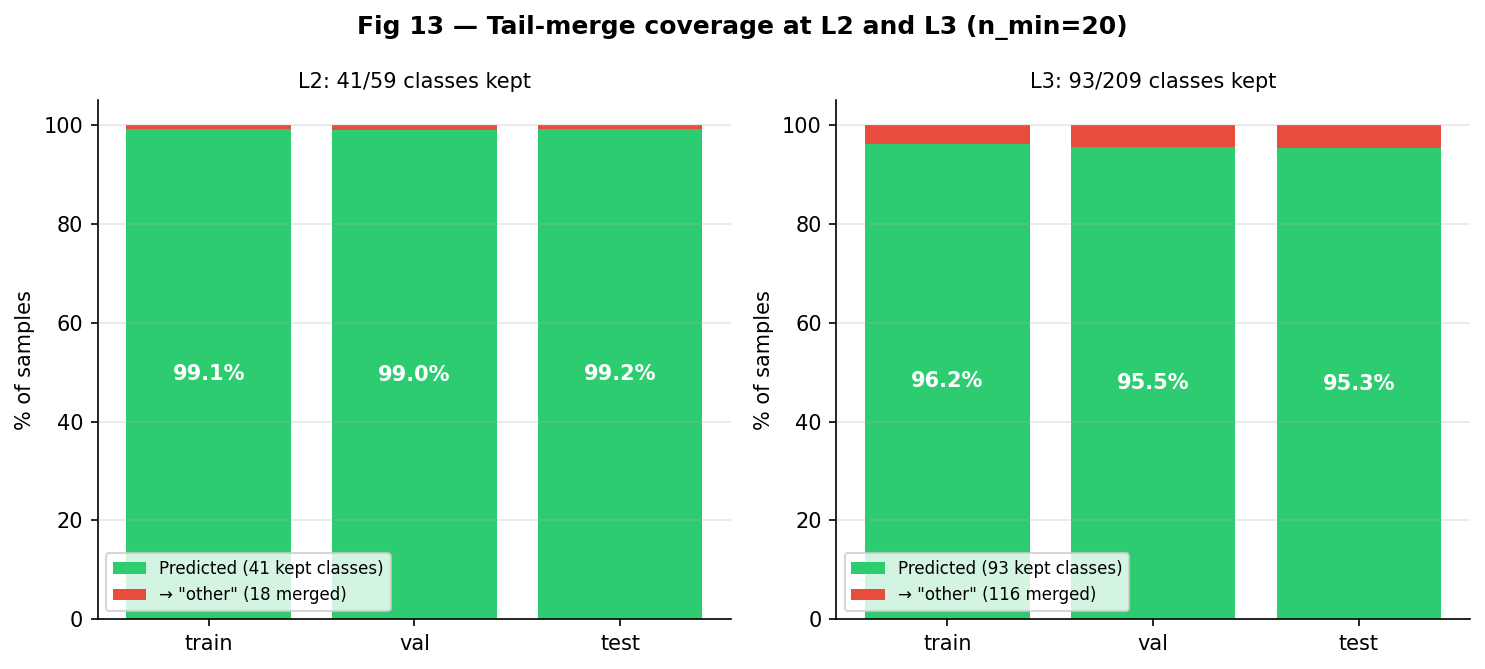

Saved fig13_tail_coverage.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Fig 13 — Tail-merge coverage at L2 and L3 (n_min=20)',
             fontsize=12, fontweight='bold')

coverage_data = {
    'L2': {'kept': 41, 'merged': 18, 'orig': 59,
           'coverage_train': 0.991, 'coverage_val': 0.990, 'coverage_test': 0.992},
    'L3': {'kept': 93, 'merged': 116, 'orig': 209,
           'coverage_train': 0.962, 'coverage_val': 0.955, 'coverage_test': 0.953},
}

for ax, level in zip(axes, ['L2', 'L3']):
    d = coverage_data[level]
    splits = ['train', 'val', 'test']
    cov = [d[f'coverage_{s}']*100 for s in splits]
    un  = [100-c for c in cov]

    bars = ax.bar(splits, cov, color='#2ecc71', label=f'Predicted ({d["kept"]} kept classes)')
    ax.bar(splits, un, bottom=cov, color='#e74c3c', label=f'→ "other" ({d["merged"]} merged)')

    for bar, c in zip(bars, cov):
        ax.text(bar.get_x() + bar.get_width()/2, c/2,
                f'{c:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

    ax.set_title(f'{level}: {d["kept"]}/{d["orig"]} classes kept', fontsize=10)
    ax.set_ylabel('% of samples'); ax.set_ylim(0, 105)
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(VIS_DIR / 'fig13_tail_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig13_tail_coverage.png')

---
## Summary: all saved figures

In [30]:
figs = sorted(VIS_DIR.glob('*.png'))
print(f'{len(figs)} figures saved to {VIS_DIR.resolve()}/')
for f in figs:
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name:<45}  {size_kb:>5} KB')

22 figures saved to /home/user/Desktop/btech_project/visuals/
  fig10_deep_vs_raw.png                             59 KB
  fig11_learning_curves.png                        267 KB
  fig12_pipeline.png                               129 KB
  fig13_tail_coverage.png                           51 KB
  fig1_vehicle_panel.png                           114 KB
  fig2_node_features.png                           189 KB
  fig3_graph_topology.png                          126 KB
  fig4_edge_weights.png                            114 KB
  fig5_edge_weight_hist.png                         55 KB
  fig6_label_hierarchy.png                         117 KB
  fig7_class_distribution.png                       69 KB
  fig8_topk_bar.png                                 90 KB
  fig9_macro_f1_heatmap.png                         56 KB
  figA_architectures.png                           238 KB
  figB_label_tree.png                              202 KB
  figC_networkx_graph.png                          749 KB
  figD_res